<a href="https://colab.research.google.com/github/Surhan-Memon/airline_tweets_dataset/blob/main/airline_tweets_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv('/content/train.csv')

In [19]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_created,tweet_location,user_timezone
0,Tr_tweet_1,neutral,1.0000,NaN,NaN,Virgin America,cairdin,0.0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,Tr_tweet_2,positive,0.3486,NaN,0.0000,Virgin America,jnardino,0.0,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,Tr_tweet_3,neutral,0.6837,NaN,NaN,Virgin America,yvonnalynn,0.0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,Tr_tweet_4,negative,1.0000,Bad Flight,0.7033,Virgin America,jnardino,0.0,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,Tr_tweet_5,negative,1.0000,Can't Tell,1.0000,Virgin America,jnardino,0.0,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


<Axes: xlabel='airline_sentiment', ylabel='count'>

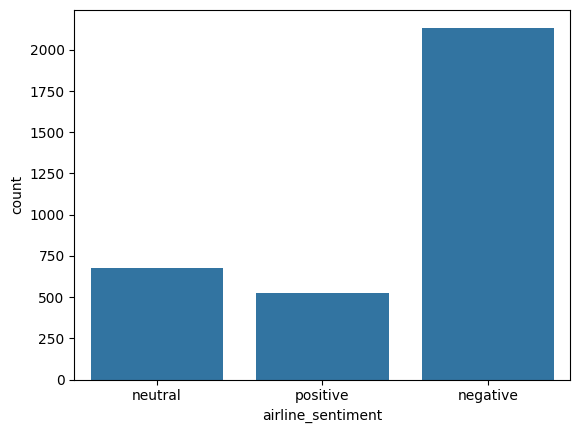

In [20]:
sns.countplot(data=df, x='airline_sentiment')

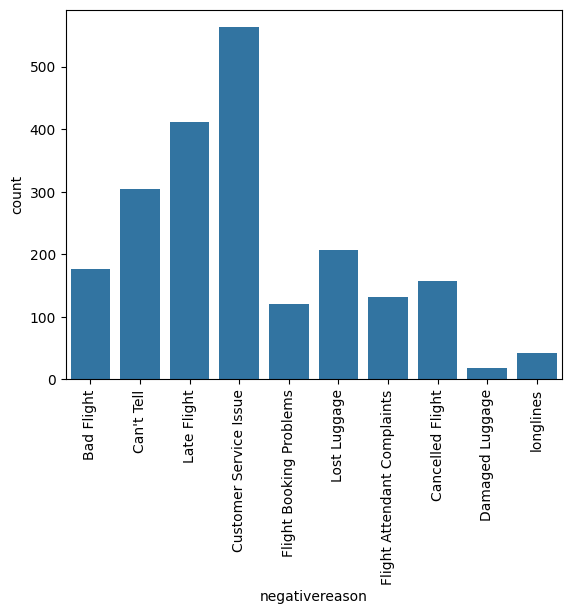

In [21]:
sns.countplot(data=df, x='negativereason')
plt.xticks(rotation=90);

<Axes: xlabel='airline', ylabel='count'>

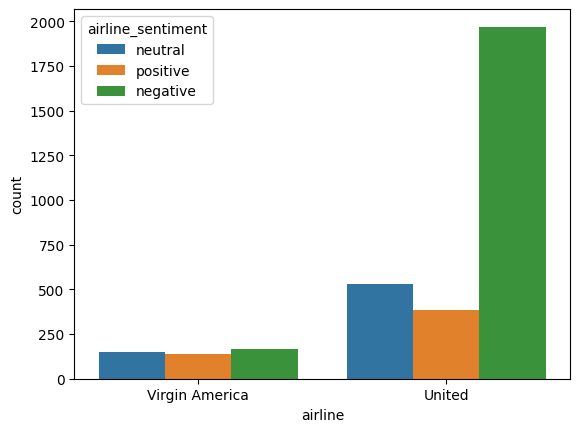

In [22]:
sns.countplot(data=df, x='airline', hue='airline_sentiment')

In [23]:
data = df[['airline_sentiment', 'text']]
data

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...
...,...,...
3334,negative,@united idea: if u don't want us to be frustra...
3335,negative,@united I will be patient in my luxurious midd...
3336,negative,@united I will be patient as your agent explai...
3337,negative,@united please help trace my luggage which was...


In [24]:
X = data['text']
y = data['airline_sentiment']

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [27]:
tfidf = TfidfVectorizer(stop_words='english')

In [29]:
X_train = X_train.fillna('').astype(str)
X_test = X_test.fillna('').astype(str)

tfidf.fit(X_train)

TfidfVectorizer(stop_words='english')

In [31]:
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [32]:
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 24229 stored elements and shape (2671, 5284)>

In [33]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [35]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [36]:
from sklearn.svm import SVC, LinearSVC

In [37]:
rbf_svc = SVC()
rbf_svc.fit(X_train_tfidf, y_train)

SVC()

In [38]:
linear_svc = LinearSVC()
linear_svc.fit(X_train_tfidf, y_train)

LinearSVC()

In [39]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [40]:
def report(model):
  preds = model.predict(X_test_tfidf)
  print(confusion_matrix(y_test, preds))
  print(classification_report(y_test, preds))
  cm = confusion_matrix(y_test, preds)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot()

[[443   1   0]
 [108   8   5]
 [ 94   1   8]]
              precision    recall  f1-score   support

    negative       0.69      1.00      0.81       444
     neutral       0.80      0.07      0.12       121
    positive       0.62      0.08      0.14       103

    accuracy                           0.69       668
   macro avg       0.70      0.38      0.36       668
weighted avg       0.70      0.69      0.58       668



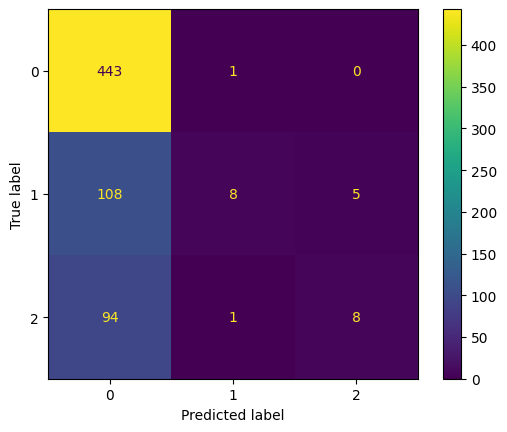

In [41]:
report(nb)

[[419  24   1]
 [ 71  32  18]
 [ 39   8  56]]
              precision    recall  f1-score   support

    negative       0.79      0.94      0.86       444
     neutral       0.50      0.26      0.35       121
    positive       0.75      0.54      0.63       103

    accuracy                           0.76       668
   macro avg       0.68      0.58      0.61       668
weighted avg       0.73      0.76      0.73       668



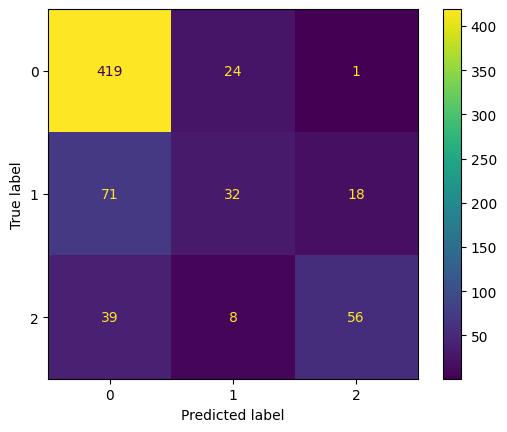

In [43]:
report(lr)

[[393  39  12]
 [ 51  44  26]
 [ 25  14  64]]
              precision    recall  f1-score   support

    negative       0.84      0.89      0.86       444
     neutral       0.45      0.36      0.40       121
    positive       0.63      0.62      0.62       103

    accuracy                           0.75       668
   macro avg       0.64      0.62      0.63       668
weighted avg       0.74      0.75      0.74       668



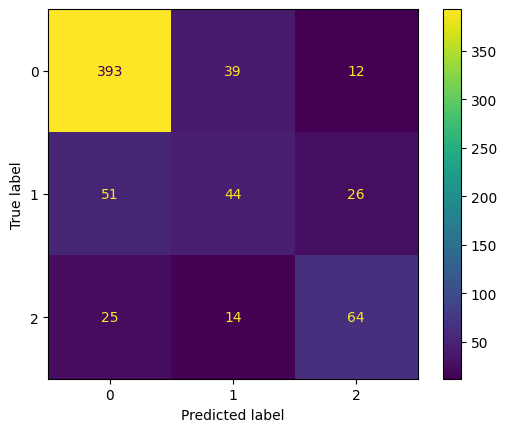

In [44]:
report(linear_svc)

In [45]:
from sklearn.pipeline import Pipeline

In [46]:
pipe = Pipeline([('tfidf', TfidfVectorizer()),
                 ('svc', LinearSVC())])

In [49]:
X = X.fillna('').astype(str)

pipe.fit(X, y)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('svc', LinearSVC())])

In [50]:
X

,text
0,@VirginAmerica What @dhepburn said.
1,@VirginAmerica plus you've added commercials t...
2,@VirginAmerica I didn't today... Must mean I n...
3,@VirginAmerica it's really aggressive to blast...
4,@VirginAmerica and it's a really big bad thing...
...,...
3334,@united idea: if u don't want us to be frustra...
3335,@united I will be patient in my luxurious midd...
3336,@united I will be patient as your agent explai...
3337,@united please help trace my luggage which was...


In [51]:
pipe.predict(['good flight'])

array(['positive'], dtype=object)

In [52]:
pipe.predict(['bad flight'])

array(['negative'], dtype=object)